In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str

graph_builder = StateGraph(AgentState)

In [3]:
from langchain_tavily import TavilySearch


tavily_search_tool = TavilySearch(
    max_results=3,
    topic="general",
    # include_answer=True,
    # include_raw_content=True,
    # include_images=True,
    # search_depth="advanced",    
)

def web_search(state: AgentState):
    query = state['query']
    search_data = tavily_search_tool.invoke(query)
    results = search_data['results']
    # results = [item for item in search_data['results']]
    print(f'web search == {results}')
    return {'context': results}

In [4]:
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt")

generate_llm = ChatOpenAI(model='gpt-5.4')

def web_generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | generate_llm | StrOutputParser()
    response =rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response}

In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

basic_llm = ChatOpenAI(model='gpt-5.4-mini')

def basic_generate(state: AgentState):
    query = state['query']
    basic_llm_chain = basic_llm | StrOutputParser()
    llm_response = basic_llm_chain.invoke(query)
    return {'answer': llm_response}

In [6]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
# from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['vector_store', 'llm', 'web_search'] = Field(
        description='The target for the query  to answer'
    )

router_system_prompt = """
You are an expert at routing a user's question to 'vector_store', 'llm', or 'web_search'.
'vector_store' contains information about income tax up to April 2026.
if you think the question is simple enough use 'llm'
if you think you need to search the web to answer the question use 'web_search'
"""

router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

router_llm = ChatOpenAI(model='gpt-5.4-mini')
structured_router_llm = router_llm.with_structured_output(Route)

def router(state: AgentState):
    query = state['query']
    router_chain = router_prompt | structured_router_llm
    route = router_chain.invoke({'query': query})
    print(f'route == {route}')
    return route.target


In [7]:
from income_tax_graph import graph as income_tax_subgraph

graph_builder.add_node('income_tax_agent', income_tax_subgraph)
graph_builder.add_node('web_search', web_search)
graph_builder.add_node('web_generate', web_generate)
graph_builder.add_node('basic_generate', basic_generate)

In [8]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'vector_store': 'income_tax_agent',
        'llm': 'basic_generate',
        'web_search': 'web_search'
    }
)

graph_builder.add_edge('web_search', 'web_generate')
graph_builder.add_edge('web_generate', END)
graph_builder.add_edge('basic_generate', END)
graph_builder.add_edge('income_tax_agent', END)

In [9]:
graph = graph_builder.compile()

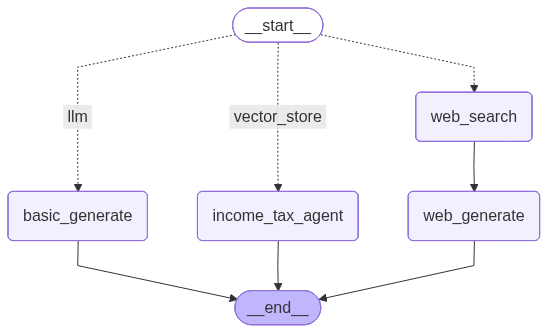

In [10]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
initial_state = {'query': '거주자의 연봉이 5천만원일 때 소득세는 얼마인가요?'}
graph.invoke(initial_state)

route == target='vector_store'
context == [Document(id='83502ad6-fd8e-4c74-8433-e1f11fcc5a2a', metadata={'article': '제55조(세율)'}, page_content='제55조(세율) ①거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 “종합소득산출세액”이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n| 구분 | 종합소득 과세표준 구간 | 세율 |\n|------|----------------------|------|\n| 1 | 1,400만원 이하 | 과세표준의 6% |\n| 2 | 1,400만원 초과 ~ 5,000만원 이하 | 84만원 + [(1,400만원 초과 금액) × 15%] |\n| 3 | 5,000만원 초과 ~ 8,800만원 이하 | 624만원 + [(5,000만원 초과 금액) × 24%] |\n| 4 | 8,800만원 초과 ~ 1억5천만원 이하 | 1,536만원 + [(8,800만원 초과 금액) × 35%] |\n| 5 | 1억5천만원 초과 ~ 3억원 이하 | 3,706만원 + [(1억5천만원 초과 금액) × 38%] |\n| 6 | 3억원 초과 ~ 5억원 이하 | 9,406만원 + [(3억원 초과 금액) × 40%] |\n| 7 | 5억원 초과 ~ 10억원 이하 | 1억 7,406만원 + [(5억원 초과 금액) × 42%] |\n| 8 | 10억원 초과 | 3억 8,406만원 + [(10억원 초과 금액) × 45%] |\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 호의 순서에 따라 계산한 금액(이하 “퇴직소득 산출세액”이라 한다)으로 한다.<개정 2013. 1. 1., 2014. 12. 23.>\n1. 해당 과세기간의 퇴직소득과세표준에 제1항의 세율을 적용하여 계산한 금액\n2

{'query': '거주자의 연봉이 5천만원일 때 소득세는 얼마인가요?',
 'context': [Document(id='83502ad6-fd8e-4c74-8433-e1f11fcc5a2a', metadata={'article': '제55조(세율)'}, page_content='제55조(세율) ①거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 “종합소득산출세액”이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n| 구분 | 종합소득 과세표준 구간 | 세율 |\n|------|----------------------|------|\n| 1 | 1,400만원 이하 | 과세표준의 6% |\n| 2 | 1,400만원 초과 ~ 5,000만원 이하 | 84만원 + [(1,400만원 초과 금액) × 15%] |\n| 3 | 5,000만원 초과 ~ 8,800만원 이하 | 624만원 + [(5,000만원 초과 금액) × 24%] |\n| 4 | 8,800만원 초과 ~ 1억5천만원 이하 | 1,536만원 + [(8,800만원 초과 금액) × 35%] |\n| 5 | 1억5천만원 초과 ~ 3억원 이하 | 3,706만원 + [(1억5천만원 초과 금액) × 38%] |\n| 6 | 3억원 초과 ~ 5억원 이하 | 9,406만원 + [(3억원 초과 금액) × 40%] |\n| 7 | 5억원 초과 ~ 10억원 이하 | 1억 7,406만원 + [(5억원 초과 금액) × 42%] |\n| 8 | 10억원 초과 | 3억 8,406만원 + [(10억원 초과 금액) × 45%] |\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 호의 순서에 따라 계산한 금액(이하 “퇴직소득 산출세액”이라 한다)으로 한다.<개정 2013. 1. 1., 2014. 12. 23.>\n1. 해당 과세기간의 퇴직소득과세표준에 제1항의 세율을 적용

In [12]:
initial_state = {'query': '대한민국의 수도는 어디입니까?'}
graph.invoke(initial_state)

route == target='llm'


{'query': '대한민국의 수도는 어디입니까?', 'answer': '대한민국의 수도는 **서울특별시**입니다.'}

In [13]:
initial_state = {'query': '역삼동 맛집은?'}
graph.invoke(initial_state)

route == target='web_search'
web search == [{'url': 'https://hotel-iu.tistory.com/1037', 'title': '역삼동 맛집 베스트 추천 top 10', 'content': "| 상호명: 바비레드 강남본점  주소: 서울특별시 강남구 역삼동 618-18 바비레드  전화번호: 미입력  관련 키워드: ['바비레드', '레드크림파스타', '바비스테이크', '매운갈비파스타', 'BOBIRED']  관련 태그: ['데이트하기 좋은', '젊고 캐쥬얼한', '모임하기 좋은']  영업시간: 매일 11:30~22:00 라스트오더 21:00 |. | 상호명: 카메참치  주소: 서울특별시 강남구 역삼동 668-9 지하1층  전화번호: 미입력  관련 키워드: ['강남식당', '역삼역참치', '일식당', '회식', '강남역참치']  관련 태그: ['단체회식', '조용한 분위기', '모임하기 좋은']  영업시간: 매일 17:00~00:00 |. | 상호명: 장인닭갈비 강남점  주소: 서울특별시 강남구 역삼동 820-1  전화번호: 미입력  관련 키워드: ['닭갈비', '점심', '밥집', '가성비', '데이트']  관련 태그: ['데이트하기 좋은', '젊고 캐쥬얼한', '모임하기 좋은']  영업시간: 매일 11:00~24:00 |. | 상호명: 어거스트 힐 강남점  주소: 서울특별시 강남구 역삼동 616-18  전화번호: 미입력  관련 키워드: ['티본스테이크', '강남역파스타', '강남스테이크', '강남역소개팅', '강남역레스토랑']  관련 태그: ['단체회식', '데이트하기 좋은', '모임하기 좋은']  영업시간: 매일 11:30~22:00 Break Time : 없음 Last Order 21:00 (식사 이용 시간 : 100분) |. | 상호명: 스시마이우 선릉역점  주소: 서울특별시 강남구 역삼동 697-45  전화번호: 미입력  관련 키워드: ['초밥', '스시', '회전초밥', '선릉초밥', '선릉역초밥']  관

{'query': '역삼동 맛집은?',
 'context': [{'url': 'https://hotel-iu.tistory.com/1037',
   'title': '역삼동 맛집 베스트 추천 top 10',
   'content': "| 상호명: 바비레드 강남본점  주소: 서울특별시 강남구 역삼동 618-18 바비레드  전화번호: 미입력  관련 키워드: ['바비레드', '레드크림파스타', '바비스테이크', '매운갈비파스타', 'BOBIRED']  관련 태그: ['데이트하기 좋은', '젊고 캐쥬얼한', '모임하기 좋은']  영업시간: 매일 11:30~22:00 라스트오더 21:00 |. | 상호명: 카메참치  주소: 서울특별시 강남구 역삼동 668-9 지하1층  전화번호: 미입력  관련 키워드: ['강남식당', '역삼역참치', '일식당', '회식', '강남역참치']  관련 태그: ['단체회식', '조용한 분위기', '모임하기 좋은']  영업시간: 매일 17:00~00:00 |. | 상호명: 장인닭갈비 강남점  주소: 서울특별시 강남구 역삼동 820-1  전화번호: 미입력  관련 키워드: ['닭갈비', '점심', '밥집', '가성비', '데이트']  관련 태그: ['데이트하기 좋은', '젊고 캐쥬얼한', '모임하기 좋은']  영업시간: 매일 11:00~24:00 |. | 상호명: 어거스트 힐 강남점  주소: 서울특별시 강남구 역삼동 616-18  전화번호: 미입력  관련 키워드: ['티본스테이크', '강남역파스타', '강남스테이크', '강남역소개팅', '강남역레스토랑']  관련 태그: ['단체회식', '데이트하기 좋은', '모임하기 좋은']  영업시간: 매일 11:30~22:00 Break Time : 없음 Last Order 21:00 (식사 이용 시간 : 100분) |. | 상호명: 스시마이우 선릉역점  주소: 서울특별시 강남구 역삼동 697-45  전화번호: 미입력  관련 키워드: ['초밥', '스시', '회전초밥', '선릉초밥', '선릉역초밥']  관련 태